In [1]:
import os

In [2]:
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [3]:
import time
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow.keras.backend as K
import cv2
import IPython
from tqdm.auto import tqdm 
from pathlib import Path
import videotools.models.RetinaFaceKeras.RetinaFace as rf
from videotools.models.RetinaFaceKeras.preprocess import preprocess_image, resize_image
from videotools.models.RetinaFaceKeras.postprocess import (
        anchors_plane, bbox_pred, clip_boxes, cpu_nms, landmark_pred
    )

2024-05-25 01:40:22.699692: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-25 01:40:23.252097: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/amos/anaconda3/envs/face/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [5]:
def draw_faces(image, faces):
    for face in faces:
        # バウンディングボックス
        x1, y1, x2, y2 = [face['x1'], face['y1'], face['x2'], face['y2']]
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(image)

In [6]:
def build_model():
    
    """
    Builds retinaface model once and store it into memory
    """
    # pylint: disable=invalid-name
    global model  # singleton design pattern

    if not "model" in globals():
        model = tf.function(
            rf.build_model(),
            input_signature=(tf.TensorSpec(shape=[None, None, None, 3], dtype=np.float16),),
        )

    return model

In [8]:
def format_predictions(predictions, frame_num):
    data = []
    for face_num, (_, prediction) in enumerate(predictions.items()):
        x1, y1, x2, y2 = [int(x) for x in prediction['facial_area']]
        datum = prediction['landmarks']
        datum['x1'] = x1
        datum['y1'] = y1 
        datum['x2'] = x2 
        datum['y2'] = y2 
        datum['confidence'] = round(prediction['score'], 3)
        datum['frame_num'] = frame_num
        datum['face_num'] = face_num
        data.append(datum)
    return data 

In [9]:
def parse_predictions(net_out,
                      im_info,
                      im_scale,
                      frame_num,
                      threshold=0.9):
    resp = {}
    proposals_list = []
    scores_list = []
    landmarks_list = []

    nms_threshold = 0.4
    decay4 = 0.5

    _feat_stride_fpn = [32, 16, 8]

    _anchors_fpn = {
        "stride32": np.array(
            [[-248.0, -248.0, 263.0, 263.0], [-120.0, -120.0, 135.0, 135.0]], dtype=np.float32
        ),
        "stride16": np.array(
            [[-56.0, -56.0, 71.0, 71.0], [-24.0, -24.0, 39.0, 39.0]], dtype=np.float32
        ),
        "stride8": np.array([[-8.0, -8.0, 23.0, 23.0], [0.0, 0.0, 15.0, 15.0]], dtype=np.float32),
    }

    _num_anchors = {"stride32": 2, "stride16": 2, "stride8": 2}

    sym_idx = 0

    for _, s in enumerate(_feat_stride_fpn):
        # _key = f"stride{s}"
        scores = net_out[sym_idx]
        scores = scores[:, :, :, _num_anchors[f"stride{s}"] :]

        bbox_deltas = net_out[sym_idx + 1]
        height, width = bbox_deltas.shape[1], bbox_deltas.shape[2]

        A = _num_anchors[f"stride{s}"]
        K = height * width
        anchors_fpn = _anchors_fpn[f"stride{s}"]
        anchors = anchors_plane(height, width, s, anchors_fpn)
        anchors = anchors.reshape((K * A, 4))
        scores = scores.reshape((-1, 1))

        bbox_stds = [1.0, 1.0, 1.0, 1.0]
        bbox_pred_len = bbox_deltas.shape[3] // A
        bbox_deltas = bbox_deltas.reshape((-1, bbox_pred_len))
        bbox_deltas[:, 0::4] = bbox_deltas[:, 0::4] * bbox_stds[0]
        bbox_deltas[:, 1::4] = bbox_deltas[:, 1::4] * bbox_stds[1]
        bbox_deltas[:, 2::4] = bbox_deltas[:, 2::4] * bbox_stds[2]
        bbox_deltas[:, 3::4] = bbox_deltas[:, 3::4] * bbox_stds[3]
        proposals = bbox_pred(anchors, bbox_deltas)

        proposals = clip_boxes(proposals, im_info[:2])

        if s == 4 and decay4 < 1.0:
            scores *= decay4

        scores_ravel = scores.ravel()
        order = np.where(scores_ravel >= threshold)[0]
        proposals = proposals[order, :]
        scores = scores[order]

        proposals[:, 0:4] /= im_scale
        proposals_list.append(proposals)
        scores_list.append(scores)

        landmark_deltas = net_out[sym_idx + 2]
        landmark_pred_len = landmark_deltas.shape[3] // A
        landmark_deltas = landmark_deltas.reshape((-1, 5, landmark_pred_len // 5))
        landmarks = landmark_pred(anchors, landmark_deltas)
        landmarks = landmarks[order, :]

        landmarks[:, :, 0:2] /= im_scale
        landmarks_list.append(landmarks)
        sym_idx += 3

    proposals = np.vstack(proposals_list)

    if proposals.shape[0] == 0:
        return resp

    scores = np.vstack(scores_list)
    scores_ravel = scores.ravel()
    order = scores_ravel.argsort()[::-1]

    proposals = proposals[order, :]
    scores = scores[order]
    landmarks = np.vstack(landmarks_list)
    landmarks = landmarks[order].astype(np.float32, copy=False)

    pre_det = np.hstack((proposals[:, 0:4], scores)).astype(np.float32, copy=False)

    # nms = cpu_nms_wrapper(nms_threshold)
    # keep = nms(pre_det)
    keep = cpu_nms(pre_det, nms_threshold)

    det = np.hstack((pre_det, proposals[:, 4:]))
    det = det[keep, :]
    landmarks = landmarks[keep]

    for idx, face in enumerate(det):
        label = "face_" + str(idx + 1)
        resp[label] = {}
        resp[label]["score"] = face[4]

        resp[label]["facial_area"] = list(face[0:4].astype(int))

        resp[label]["landmarks"] = {}
        resp[label]["landmarks"]["right_eye"] = list(landmarks[idx][0])
        resp[label]["landmarks"]["left_eye"] = list(landmarks[idx][1])
        resp[label]["landmarks"]["nose"] = list(landmarks[idx][2])
        resp[label]["landmarks"]["mouth_right"] = list(landmarks[idx][3])
        resp[label]["landmarks"]["mouth_left"] = list(landmarks[idx][4])
    data = format_predictions(resp, frame_num)
    return data

In [10]:
def batch_parse_predictions(out, frames):
    data = []
    for i in range(len(frames)):
        frame_num, frame = frames[i]
        _, im_info, im_scale = preprocess_image(frame, True)
        a = [np.expand_dims(x[i, :, :, :], axis=0) for x in out]
        datum = parse_predictions(a, im_info, im_scale, frame_num)
        data.append(datum) 
    return data

In [11]:
model = rf.build_model()

In [12]:
img = cv2.imread('../images/img_1.jpg')
im_tensor, im_info, im_scale = preprocess_image(img, True)
out_net = model(im_tensor)
out_net = [elt.numpy() for elt in out_net]

2024-05-25 01:41:18.725535: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8902
W0000 00:00:1716615678.789595    6294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1716615678.824420    6294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1716615678.825898    6294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1716615678.827459    6294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1716615678.829233    6294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1716615678.831251    6294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1716615678.834177    6294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1716615678.836438    6294 gpu_t

In [12]:
parse_predictions(out_net, im_info, im_scale, 1)

[{'right_eye': [441.74496, 355.54904],
  'left_eye': [457.38266, 354.54642],
  'nose': [449.61444, 364.04474],
  'mouth_right': [444.9446, 370.43228],
  'mouth_left': [456.532, 369.6425],
  'x1': 433,
  'y1': 339,
  'x2': 467,
  'y2': 378,
  'confidence': 1.0,
  'frame_num': 1,
  'face_num': 0},
 {'right_eye': [223.98755, 249.93497],
  'left_eye': [240.08716, 249.13647],
  'nose': [232.25276, 258.45807],
  'mouth_right': [226.66054, 265.82806],
  'mouth_left': [238.50081, 265.21304],
  'x1': 215,
  'y1': 232,
  'x2': 249,
  'y2': 274,
  'confidence': 1.0,
  'frame_num': 1,
  'face_num': 1},
 {'right_eye': [483.75726, 255.44017],
  'left_eye': [499.32312, 255.06337],
  'nose': [491.5013, 265.16595],
  'mouth_right': [485.87372, 271.5509],
  'mouth_left': [498.0904, 271.26736],
  'x1': 475,
  'y1': 237,
  'x2': 508,
  'y2': 281,
  'confidence': 0.999,
  'frame_num': 1,
  'face_num': 2},
 {'right_eye': [147.27806, 371.00143],
  'left_eye': [162.61038, 369.34525],
  'nose': [156.03595, 379

In [13]:
images = [cv2.imread('/home/amos/programs/CineFace/research/test_images/Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png'),
          cv2.imread('/home/amos/programs/CineFace/research/test_images/Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png')]
a = np.array(images)

In [14]:
t = time.time()
out = model(a)
out = [x.numpy() for x in out]
data = []
im_tensor, im_info, im_scale = preprocess_image(images[0], True)
for i in range(len(images)):
    l = [np.expand_dims(x[i, :, :, :], axis=0) for x in out]
    datum = parse_predictions(l, im_info, im_scale, 1)
    data.append(datum)
print(time.time() - t)

3.0060198307037354


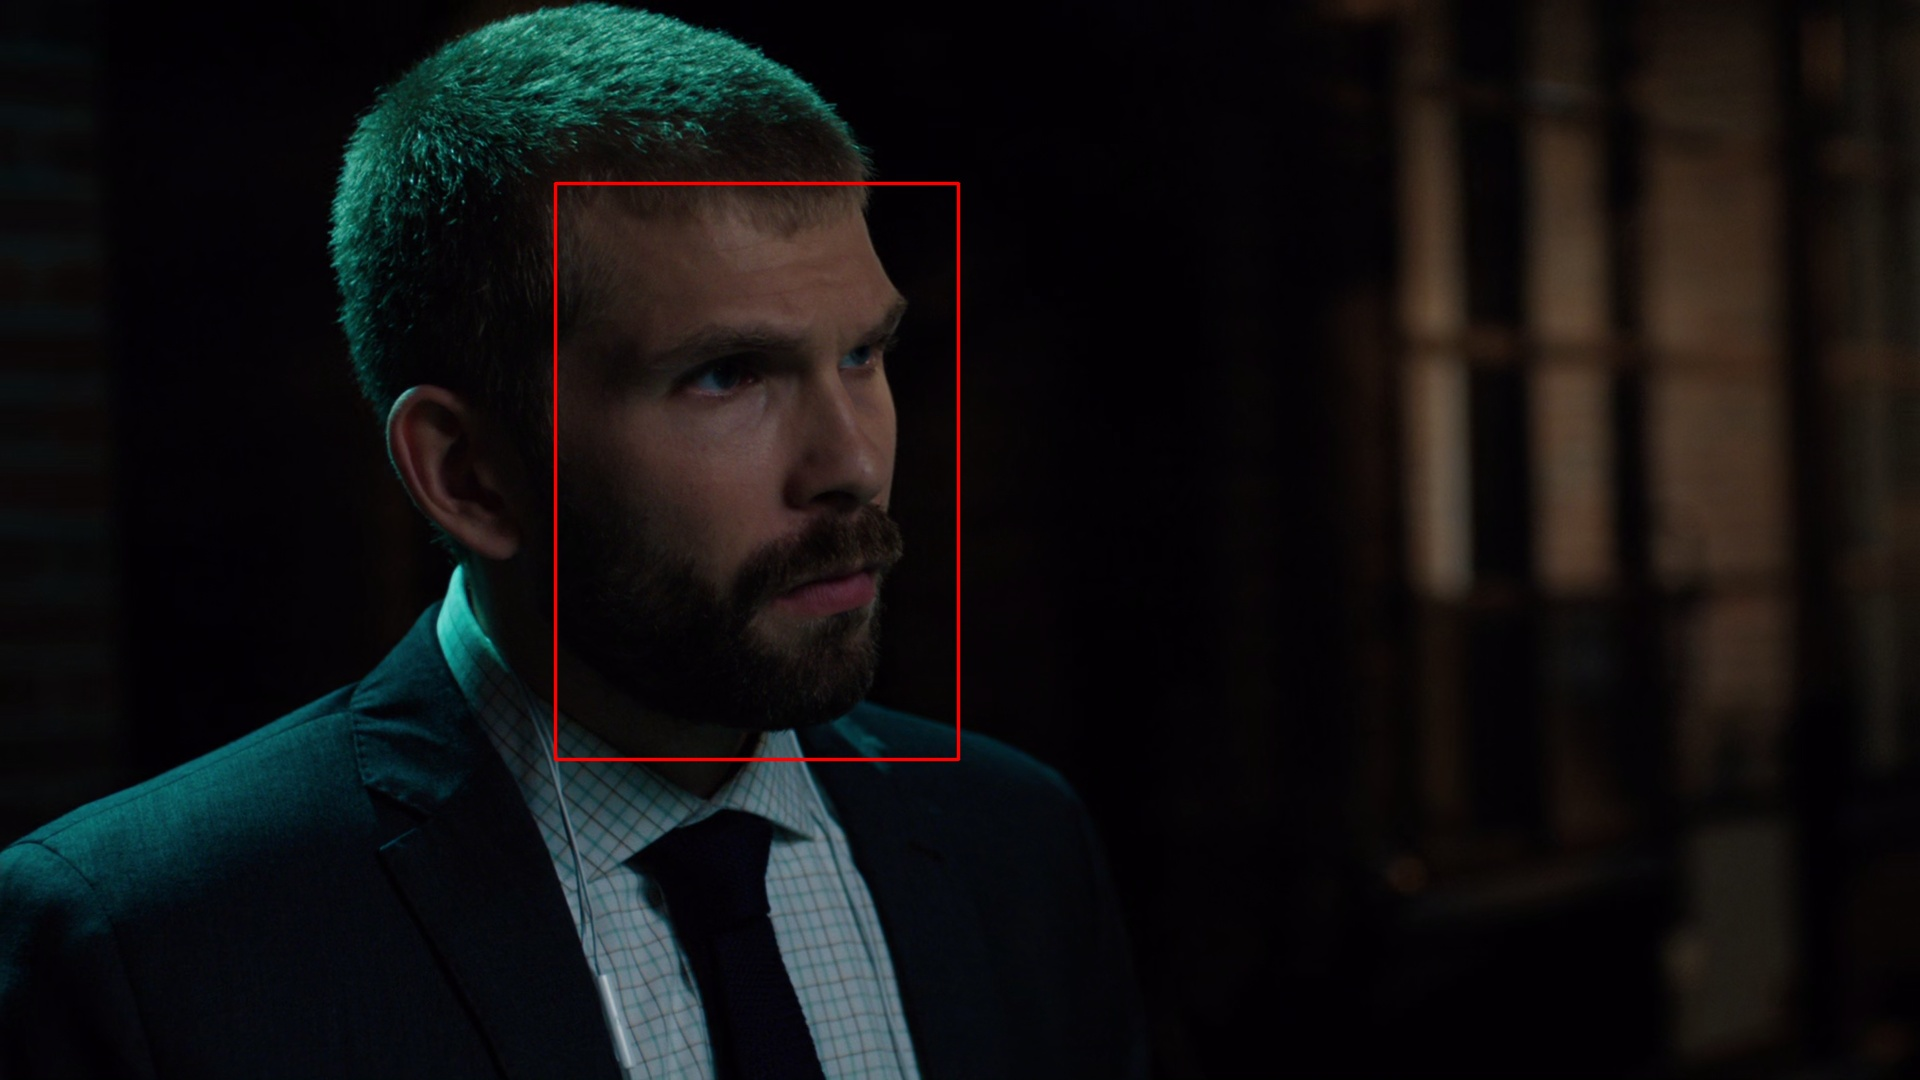

In [16]:
draw_faces(a[0], data[0])

In [18]:
t = time.time()
for i in images:
    im_tensor, im_info, im_scale = preprocess_image(i, True)
    out = model(im_tensor)
    out = [elt.numpy() for elt in out]
    datum = parse_predictions(out, im_info, im_scale, 1)
print(time.time() - t)

0.31108522415161133


In [17]:
src_1 = '/home/amos/programs/CineFace/data/test_videos/shining_bat.mp4'
src_2 = '/home/amos/media/tv/Succession.1080p.S01-04.2018.WebRip.x265.10Bit.AC3.5.1-JATT/Succession.2018.S01.1080p.WebRip.x265.10Bit.AC3.5.1-JATT/Succession.2018.S01E01.Celebration.1080p.WebRip.x265.10Bit.AC3.5.1-JATT.mkv'

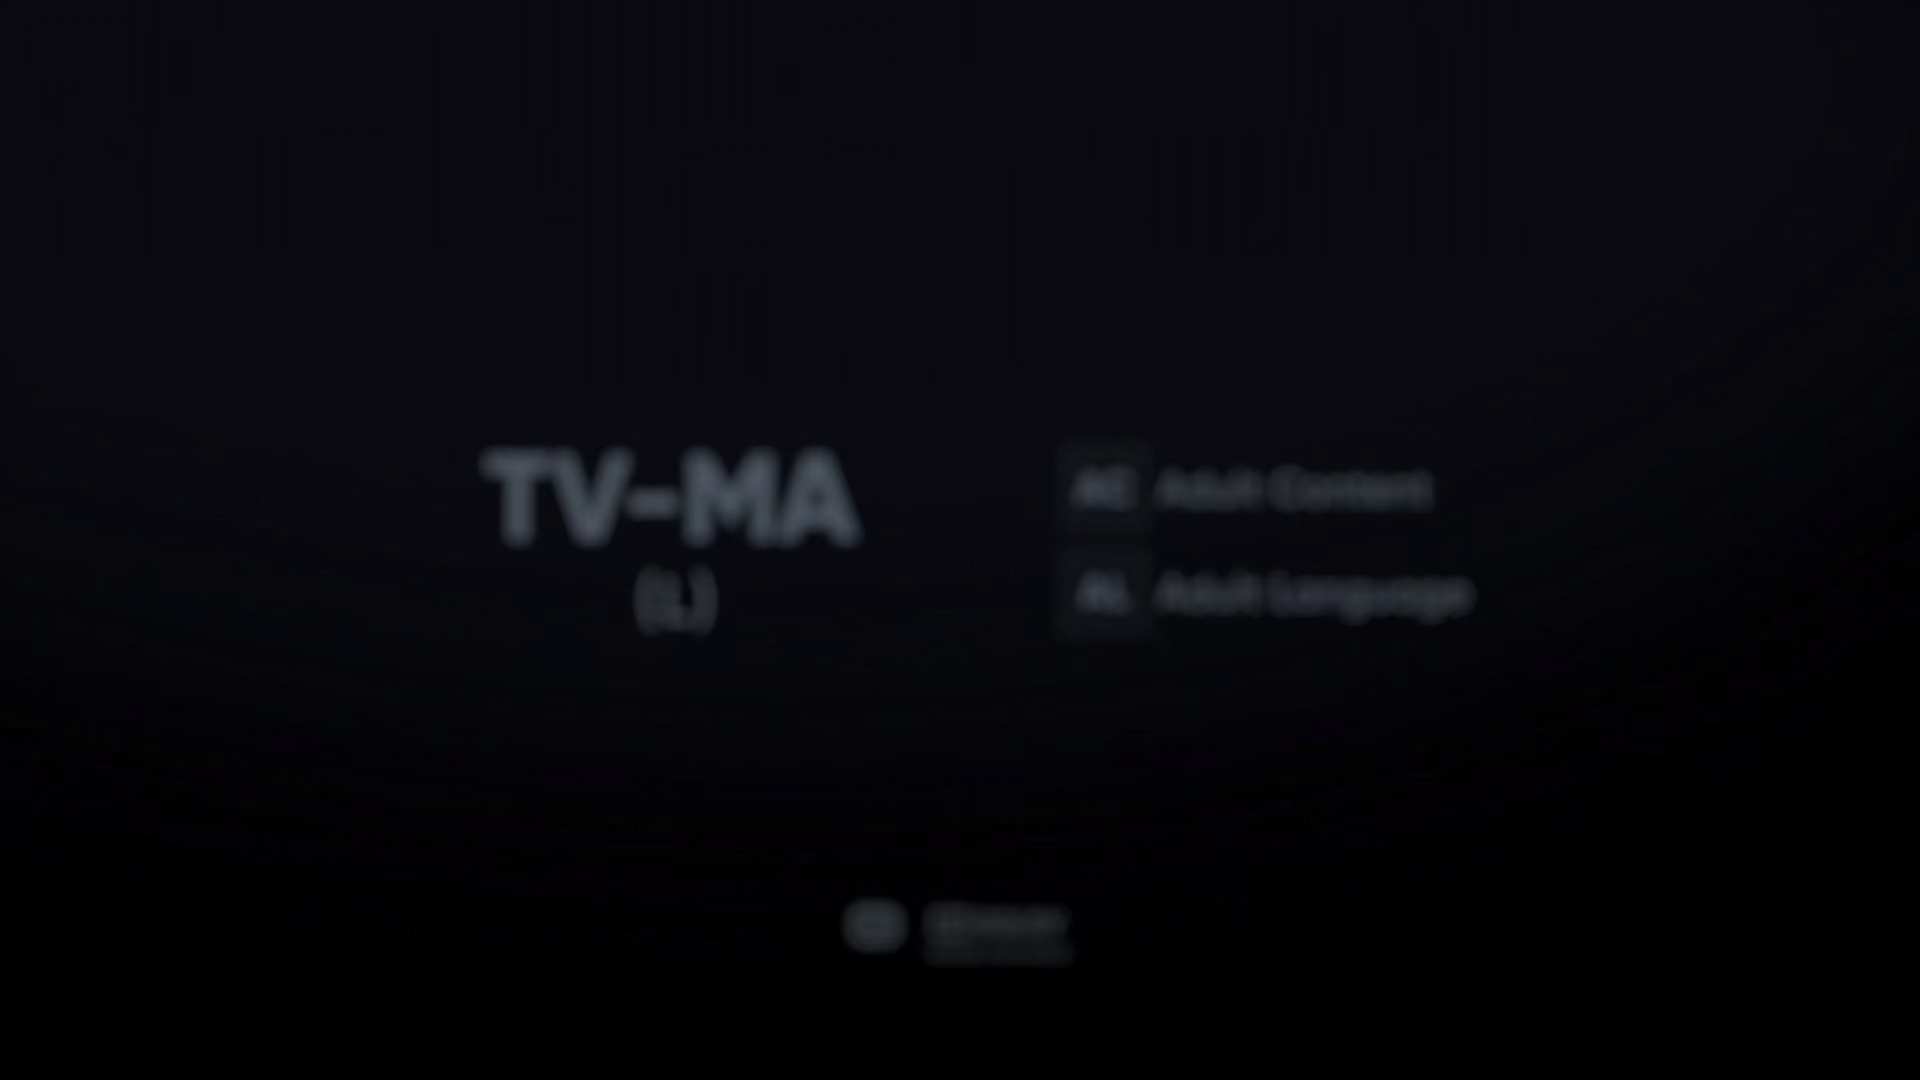

In [24]:
cap = cv2.VideoCapture(src_2)
ret, frame = cap.read()
show_image(frame)

  0%|          | 0/8553 [00:00<?, ?it/s]

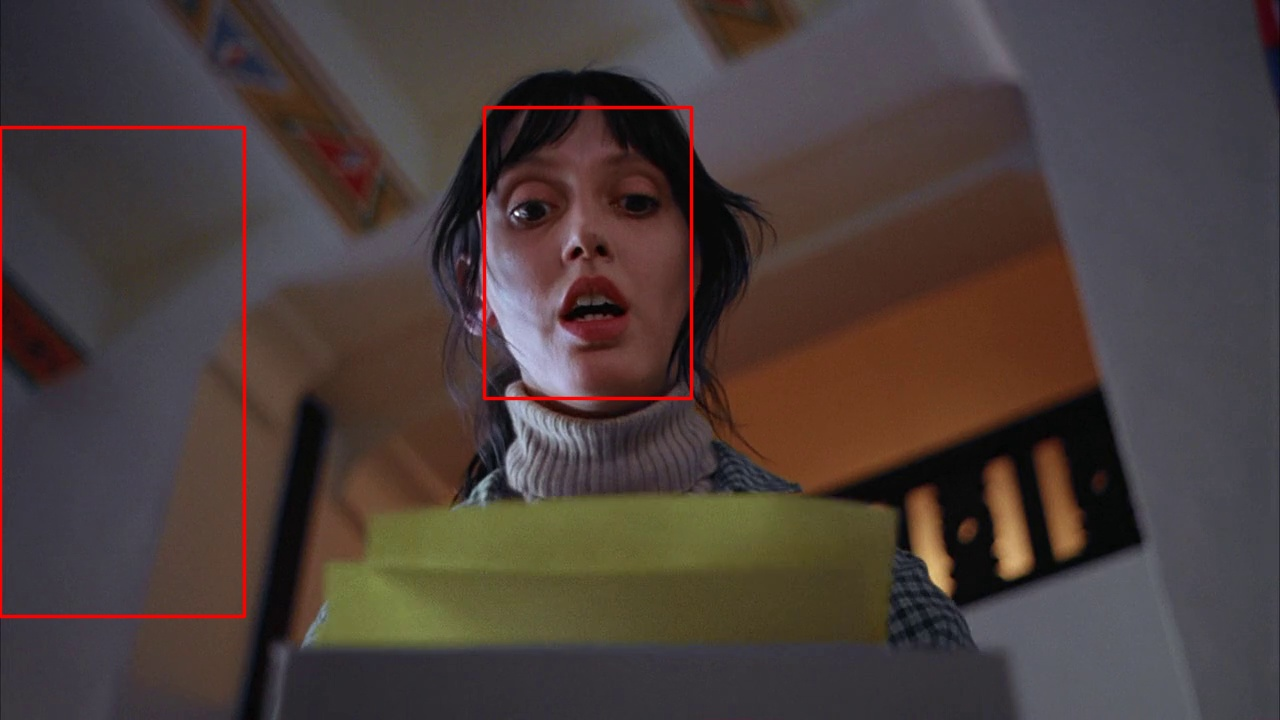

24


In [19]:
cap = cv2.VideoCapture(src_1)
cnt = 1
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pb = tqdm(total=framecount)
while True:
    ret, frame = cap.read()
    if not ret or frame is None:
            break 
    elif cnt % 24 == 0:
        im_tensor, im_info, im_scale = preprocess_image(frame, True)
        out_net = model(im_tensor)
        out_net = [elt.numpy() for elt in out_net]
        faces = parse_predictions(out_net, im_info, im_scale, 1)
        if not faces:
            pb.update(1)
            cnt += 1
            continue
        draw_faces(frame, faces)
        break
    cnt += 1
    pb.update(1)
print(cnt)

0it [00:43, ?it/s]

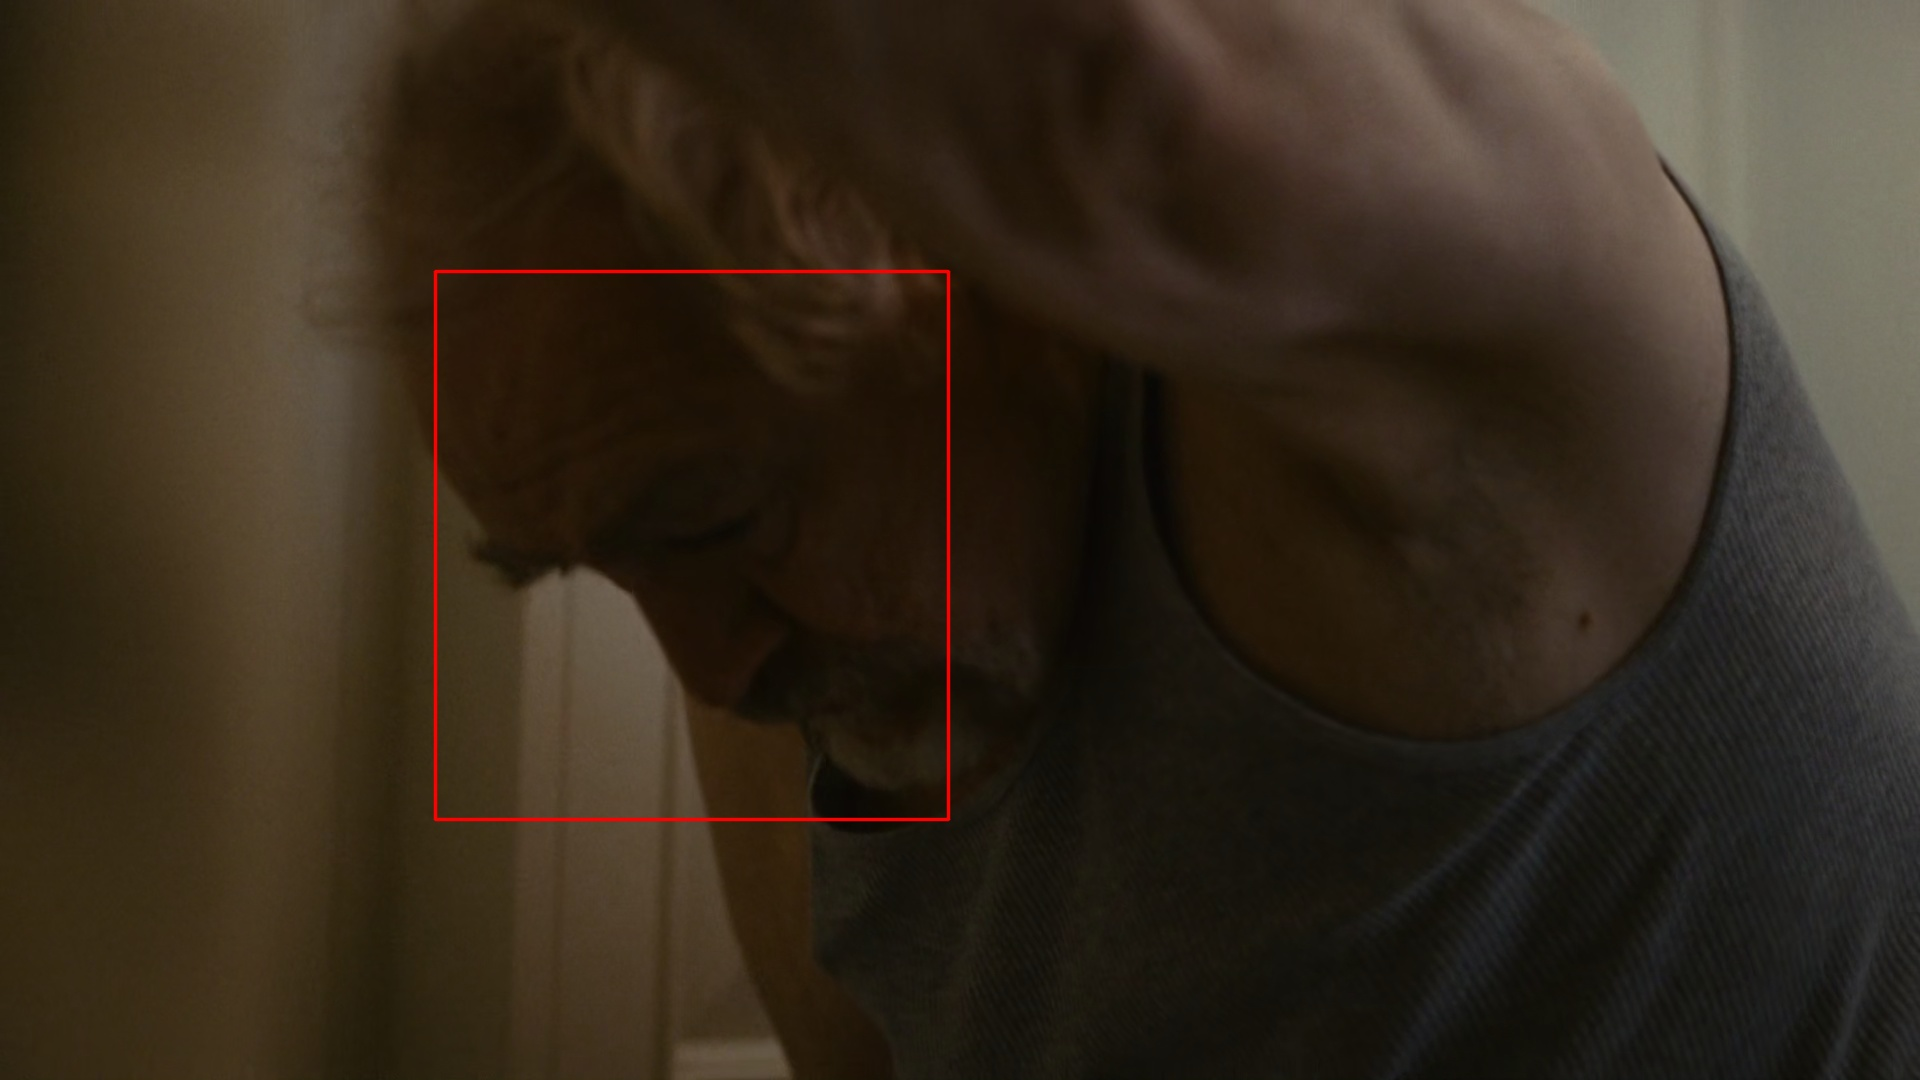

2112


In [25]:
cap = cv2.VideoCapture(src_2)
cnt = 1
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pb = tqdm(total=framecount)
while True:
    ret, frame = cap.read()
    if not ret or frame is None:
            break 
    elif cnt % 24 == 0:
        im_tensor, im_info, im_scale = preprocess_image(frame, True)
        out_net = model(im_tensor)
        out_net = [elt.numpy() for elt in out_net]
        faces = parse_predictions(out_net, im_info, im_scale, 1)
        if not faces:
            pb.update(1)
            cnt += 1
            continue
        draw_faces(frame, faces)
        break
    cnt += 1
    pb.update(1)
print(cnt)

In [26]:
cap = cv2.VideoCapture(src_2)
cnt = 1
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pb = tqdm(total=framecount)
frames = []
info = []
scales = []
while True:
    ret, frame = cap.read()
    if not ret or frame is None:
        print(cnt)
        break 
    elif cnt % 24 == 0:
        frames.append((cnt, frame))

    if len(frames) >= 8:
        images = [x[1] for x in frames]
        im_tensor, im_info, im_scale = preprocess_image(frame, True)
        tensors = [preprocess_image(x, True)[0][0, :, :, :] for x in images]
        a = np.array(tensors)
        out_net = model(a)
        out_net = [elt.numpy() for elt in out_net]
        faces = batch_parse_predictions(out_net, frames)
        if any(faces):
            break
        frames = []
    cnt += 1
    pb.update(1)
print(cnt)

  2%|▏         | 2111/88890 [00:32<22:05, 65.47it/s]


  2%|▏         | 2104/88890 [00:24<09:53, 146.27it/s]

2112


  2%|▏         | 2111/88890 [00:37<09:53, 146.27it/s]

In [27]:
faces

[{},
 {},
 {},
 {},
 {},
 {},
 {},
 [{'right_eye': [620.71387, 591.27014],
   'left_eye': [759.1865, 543.8226],
   'nose': [718.541, 696.1941],
   'mouth_right': [684.6282, 734.49],
   'mouth_left': [786.17914, 696.9682],
   'x1': 435,
   'y1': 271,
   'x2': 948,
   'y2': 819,
   'confidence': 0.976,
   'frame_num': 2112,
   'face_num': 0}]]

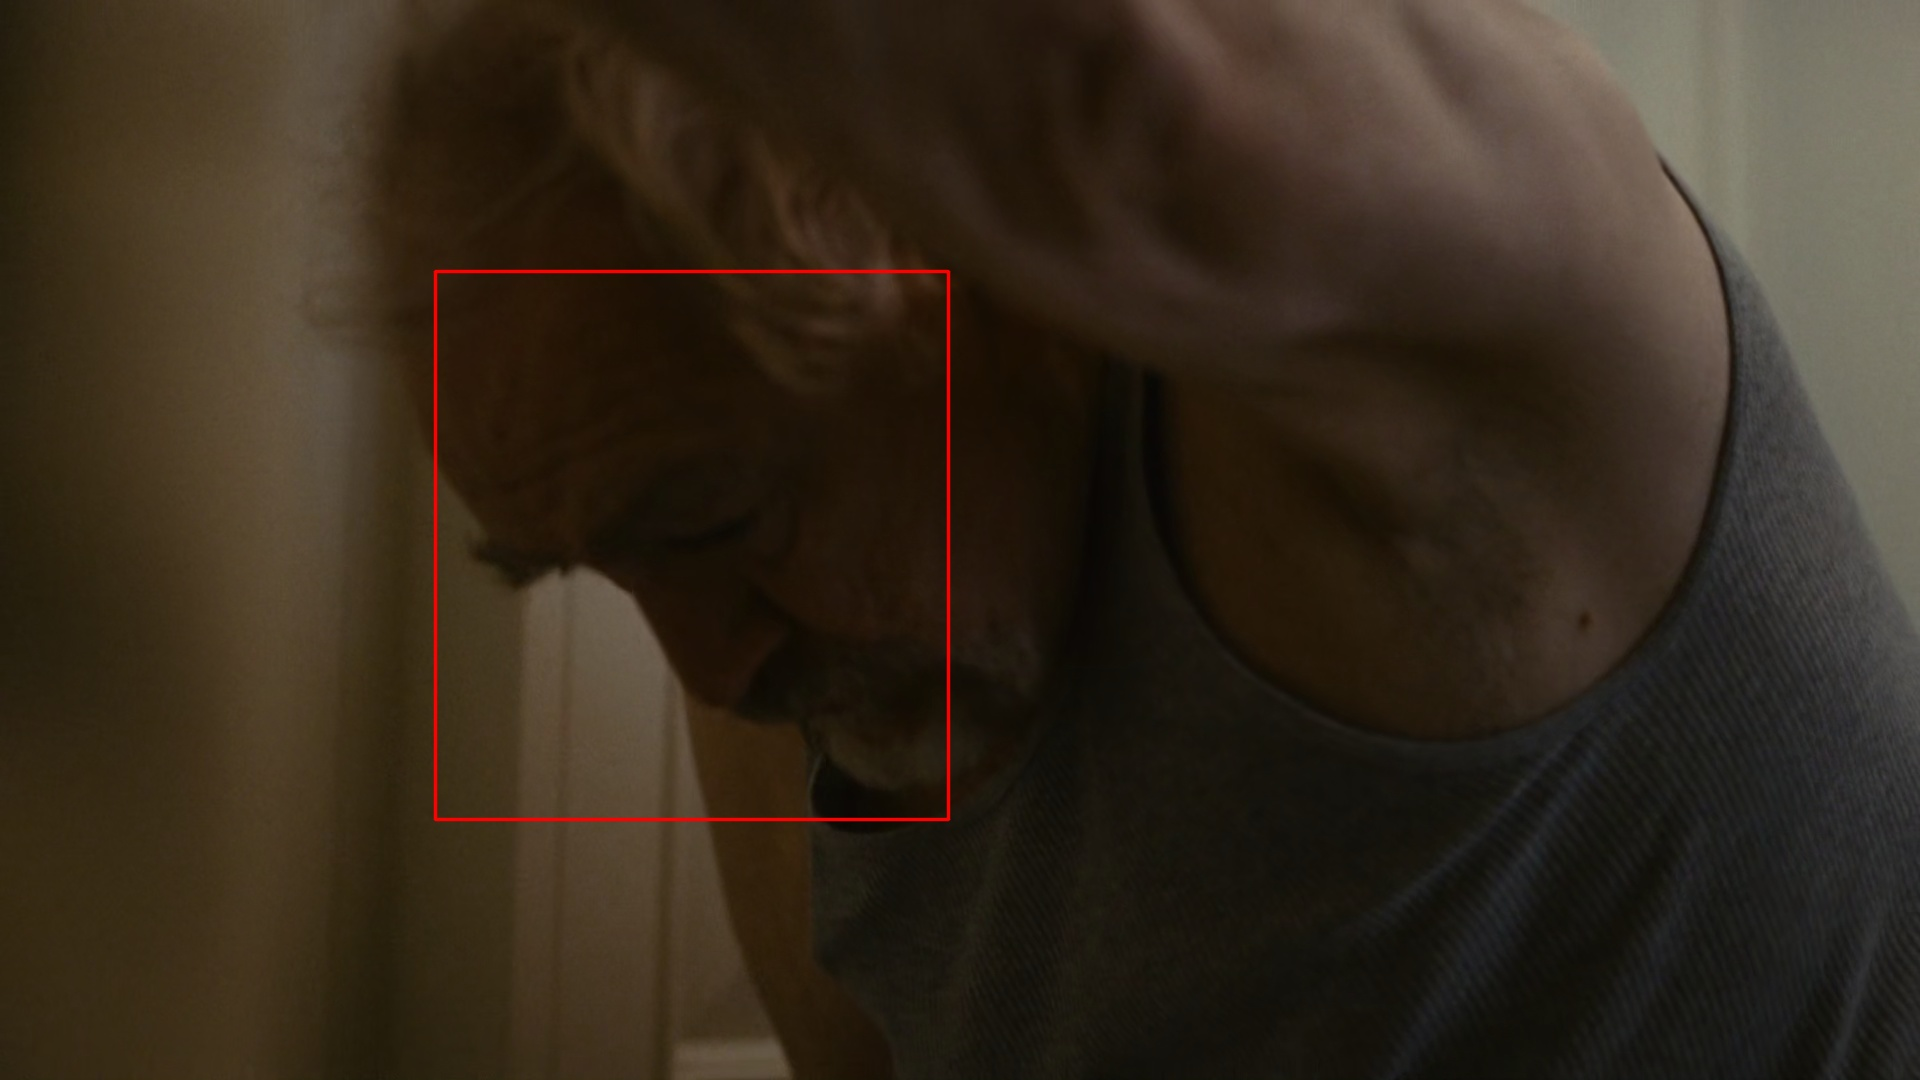

In [29]:
draw_faces(images[-1], faces[-1])

In [50]:
a.shape

(2, 1080, 1920, 3)